In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#loading last week's assets
import numpy as np
X_latent_16d = np.load("/content/drive/MyDrive/Lion-Biologging-SoS'26/X_latent_16d.npy")
tsne_result = np.load("/content/drive/MyDrive/Lion-Biologging-SoS'26/tsne_results_2d.npy")

In [3]:
print(X_latent_16d.shape)
print(tsne_result.shape)


(15952, 16)
(15952, 2)


In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

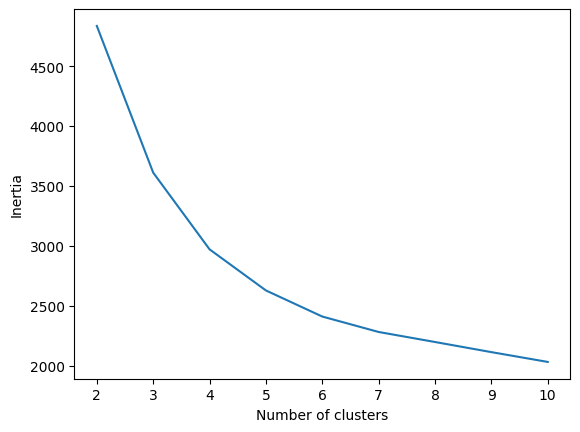

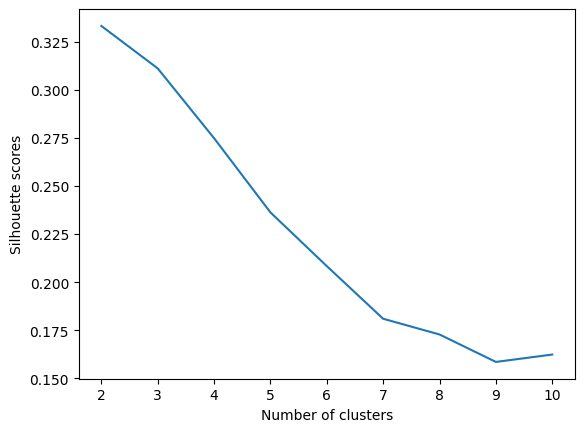

In [5]:
#finding the optimal K (elbow method)
k_range = range(2,11)
inertia = []
scores = []
for k in k_range:
  kmeans = KMeans(n_clusters=k,init="k-means++",random_state=7)
  labels = kmeans.fit(X_latent_16d)
  inertia.append(kmeans.inertia_)
  #using silhoutte scores to verify
  scores.append(silhouette_score(X_latent_16d,labels.labels_))

plt.plot(k_range,inertia)
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

plt.plot(k_range,scores)
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette scores")
plt.show()


In [12]:
#k=4 makes the perfect clusters
n_means = 4
k_means = KMeans(n_means,init="k-means++",random_state=7)
labels_kmeans = k_means.fit_predict(X_latent_16d)
print(labels.shape)

(15952,)


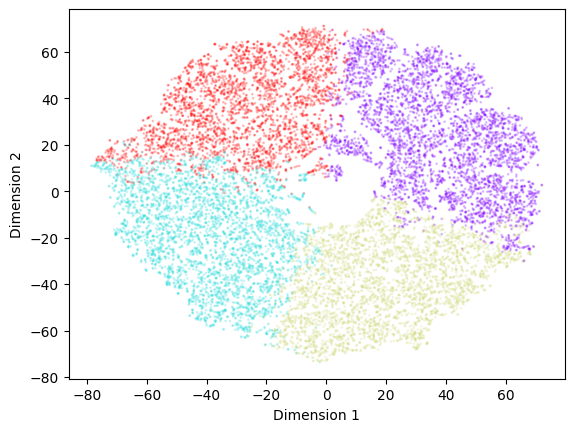

In [18]:
plt.scatter(tsne_result[:,0],tsne_result[:,1],c=labels_kmeans,cmap="rainbow",s=1,alpha=0.2)
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.savefig("/content/drive/MyDrive/Lion-Biologging-SoS'26/images/kmeans_clusters_2d.png",dpi=300,bbox_inches='tight')
plt.show()

In [9]:
#implementing the more dynamic gaussian mixture model
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=n_means,covariance_type='full',random_state=7)
labels_gmm = gmm.fit_predict(X_latent_16d)


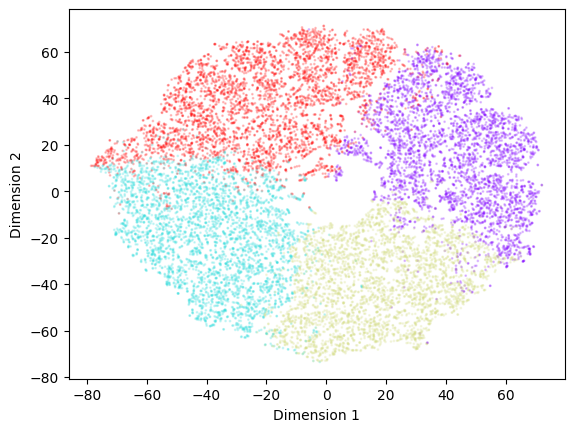

In [19]:
plt.scatter(tsne_result[:,0],tsne_result[:,1],c=labels_gmm,cmap="rainbow",s=1,alpha=0.2)
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.savefig("/content/drive/MyDrive/Lion-Biologging-SoS'26/images/gmm_clusters_2d.png",dpi=300,bbox_inches='tight')
plt.show()

In [20]:
np.save("/content/drive/MyDrive/Lion-Biologging-SoS'26/features/labels_kmeans.npy",labels_kmeans)
np.save("/content/drive/MyDrive/Lion-Biologging-SoS'26/features/labels_gmm.npy",labels_gmm)